**Task 2: Quantitative analysis using pynance and TaLib**

Objective: Load historical stock price data, compute financial technical indicators, and
visualize the results to understand market behavior.


In [1]:
%load_ext autoreload
%autoreload 2
import sys
import os

# 1. Tell the notebook where to find your 'src' folder
sys.path.append(os.path.abspath('../'))

1. Prepare Your Data


In [2]:
# Import your custom modules
from src.data_loader import load_stock_data, process_financial_data

# Define file path
goog_path = "../data/raw/goog.csv"

# Load raw dataset
print("Loading raw data for goog...")
raw_goog = load_stock_data(goog_path)

# Clean dataset
print("Applying financial cleaning rules...")
clean_goog = process_financial_data(raw_goog)


# Check data types
print(clean_goog.dtypes)

# Missing values
print("Missing Values Remaining")
print(clean_goog.isnull().sum())

# Preview dataset
print("Preview of the Clean goog Dataset")
print(clean_goog.head())

Loading raw data for goog...
Applying financial cleaning rules...
Date      datetime64[us, UTC]
Close                 float64
High                  float64
Low                   float64
Open                  float64
Volume                  int64
dtype: object
Missing Values Remaining
Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64
Preview of the Clean goog Dataset
                       Date     Close      High       Low      Open     Volume
0 2009-01-02 00:00:00+00:00  7.948608  7.960977  7.557264  7.633949  144961322
1 2009-01-05 00:00:00+00:00  8.115089  8.194003  7.792268  7.940692  196293007
2 2009-01-06 00:00:00+00:00  8.263762  8.430492  8.074027  8.237046  257971329
3 2009-01-07 00:00:00+00:00  7.965677  8.185839  7.885034  8.121770  180453860
4 2009-01-08 00:00:00+00:00  8.044340  8.044340  7.850152  7.873406  144567852


**2. Compute Technical Indicators with TA-Lib**

In [3]:
from src.indicators import add_moving_averages, add_rsi, add_macd, add_financial_metrics

print("Computing technical indicators for goog...")

# Apply the mathematical transformations sequentially
clean_goog = add_moving_averages(clean_goog)
clean_goog = add_rsi(clean_goog)
clean_goog = add_macd(clean_goog)

# Apply the financial metrics (This creates the 'Daily_Return' column!)
clean_goog = add_financial_metrics(clean_goog)

print(" Indicators computed successfully! Previewing results:")
clean_goog[
    [
        'Date', 
        'Close', 
        'SMA_20', 
        'RSI', 
        'MACD', 
        'Daily_Return'
    ]
].tail()

2026-05-10 10:59:13,038 - WARNING - PyNance calculation skipped: module 'pynance' has no attribute 'tech'


Computing technical indicators for goog...
 Indicators computed successfully! Previewing results:


,Date,Close,SMA_20,RSI,MACD,Daily_Return
3769,2023-12-22 00:00:00+00:00,141.750000,135.009596,64.953309,1.412015,0.006488
3770,2023-12-26 00:00:00+00:00,141.849304,135.246477,65.115870,1.706565,0.000701
3771,2023-12-27 00:00:00+00:00,140.478683,135.386520,60.916026,1.808553,-0.009663
3772,2023-12-28 00:00:00+00:00,140.319748,135.628861,60.429303,1.855168,-0.001131
3773,2023-12-29 00:00:00+00:00,139.972137,135.976979,59.313063,1.842820,-0.002477


**Apply PyNance for Financial Metrics**

In [4]:
from src.financial_metrics import add_financial_metrics

clean_goog = add_financial_metrics(clean_goog)

# Pass the analyzed_goog dataframe you generated in the previous step
clean_goog = add_financial_metrics(clean_goog)
print("Metrics computed successfully!")
clean_goog[['Date', 'Returns', 'Volatility_20', 'Cumulative_Return']].tail()

Metrics computed successfully!


,Date,Returns,Volatility_20,Cumulative_Return
3769,2023-12-22 00:00:00+00:00,0.006488,0.017215,17.833310
3770,2023-12-26 00:00:00+00:00,0.000701,0.017203,17.845804
3771,2023-12-27 00:00:00+00:00,-0.009663,0.017382,17.673368
3772,2023-12-28 00:00:00+00:00,-0.001131,0.016921,17.653373
3773,2023-12-29 00:00:00+00:00,-0.002477,0.016293,17.609641


**Visualize the Data**


Generating Price & Moving Averages Chart...


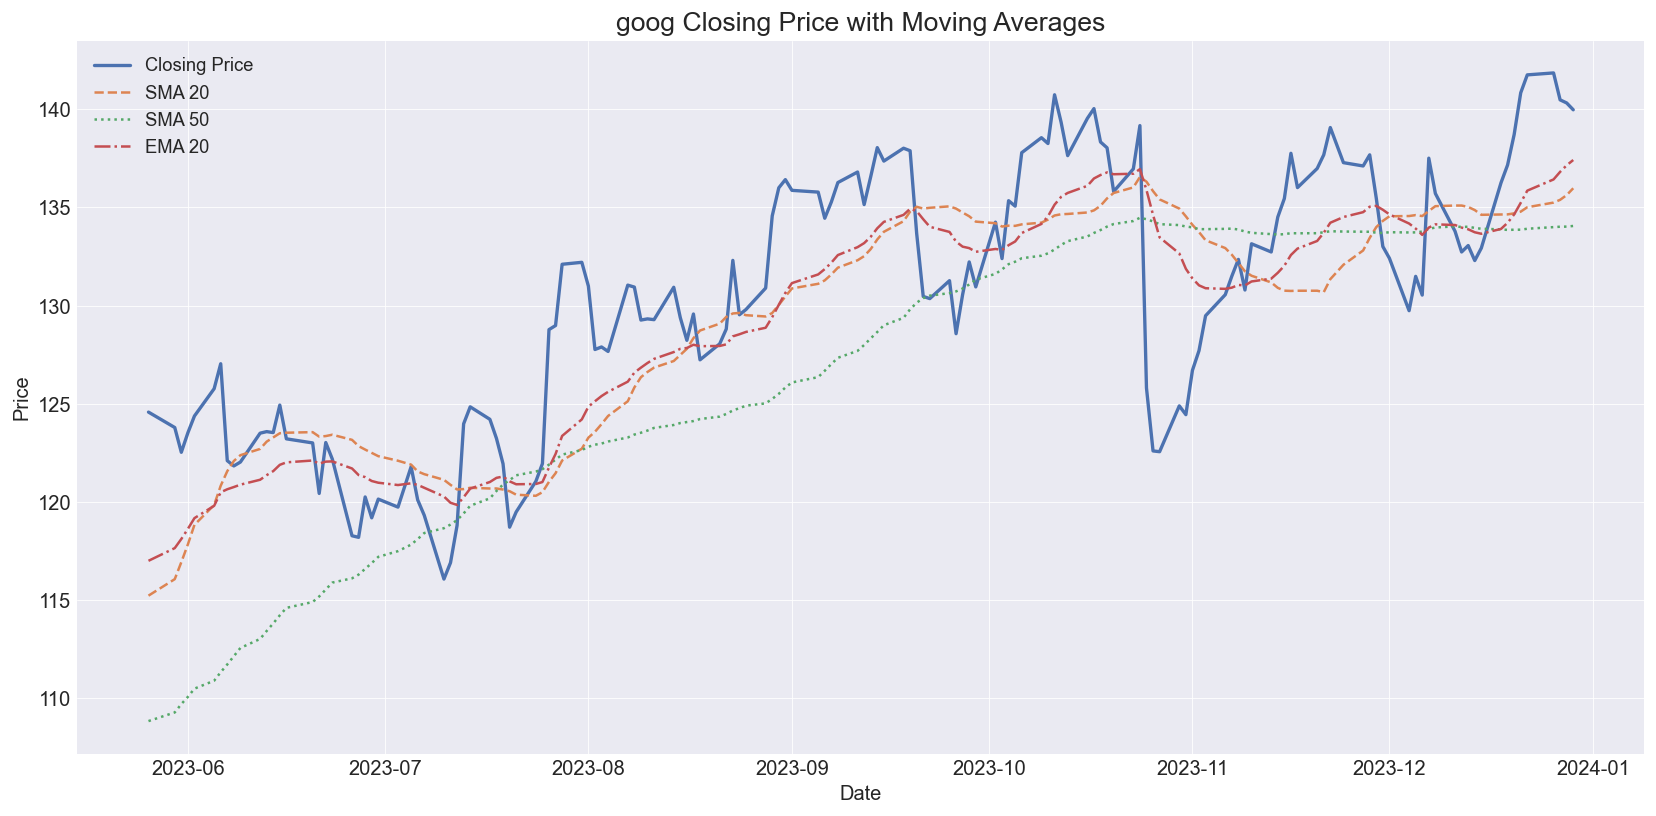

In [5]:
from src.visuals import set_visual_style, plot_price_and_ma, plot_rsi, plot_macd

# Apply the global darkgrid style
set_visual_style()

symbol = 'goog'

# 1. Plot Price and Moving Averages
print("Generating Price & Moving Averages Chart...")
plot_price_and_ma(clean_goog, symbol)

Generating RSI Chart...


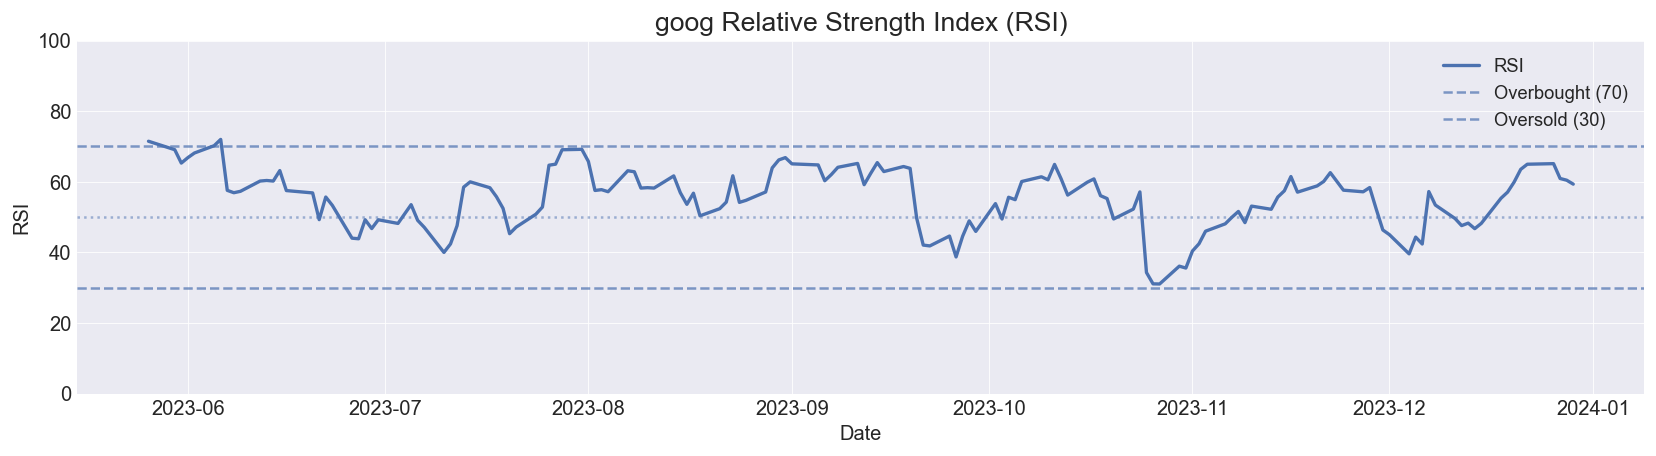

In [6]:
# 2. Plot Relative Strength Index
print("Generating RSI Chart...")
plot_rsi(clean_goog, symbol)

Generating MACD Chart...


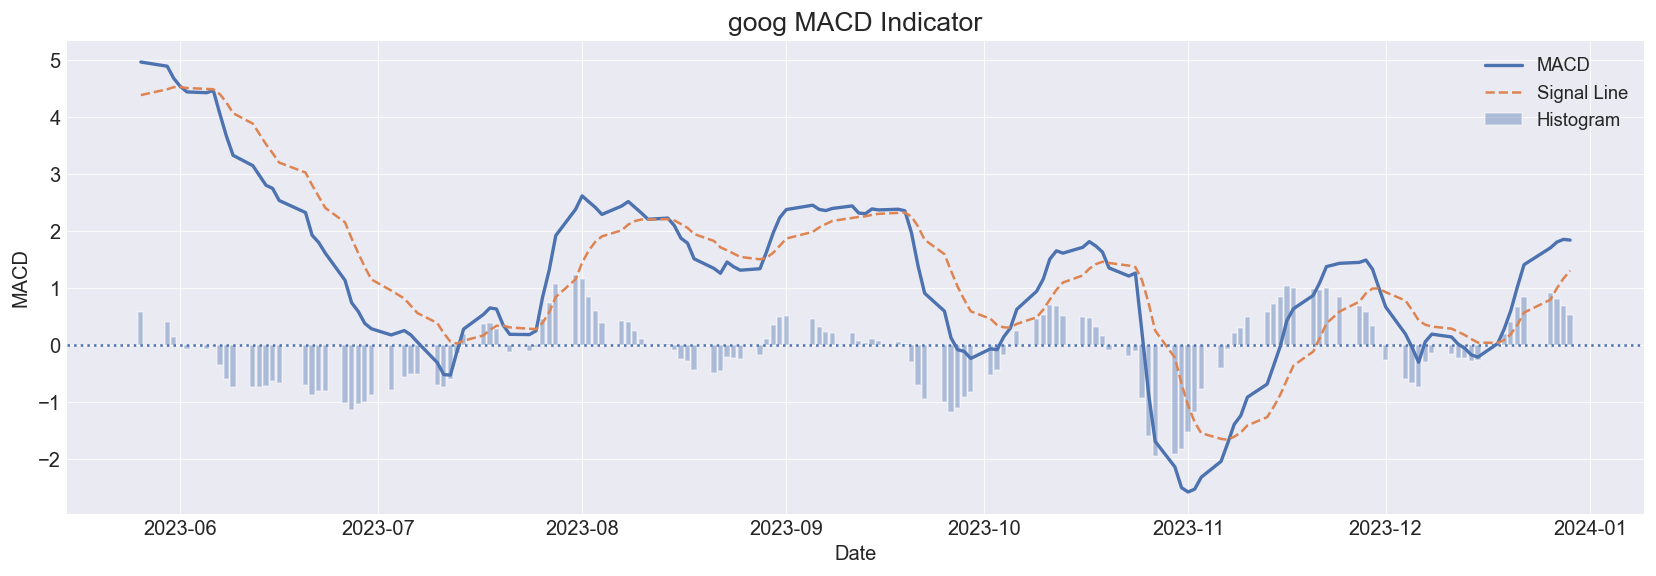

In [7]:
# 3. Plot MACD
print("Generating MACD Chart...")
plot_macd(clean_goog, symbol)

In [8]:
# save the processed dataset for task 3
import os

# Ensure the directory exists
os.makedirs("../data/processed", exist_ok=True)

# Save the finalized dataset
processed_goog_path = f"../data/processed/{symbol}_processed.csv"
clean_goog.to_csv(processed_goog_path, index=False)

print(f" {symbol} quantitative analysis complete and saved to {processed_goog_path}")

 goog quantitative analysis complete and saved to ../data/processed/goog_processed.csv
